#### 손가락 숫자 모양의 Image 분류

##### Data 불러오기

In [1]:
import glob 
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
train_images = glob.glob("../Data/fingers/train/*.png")

In [3]:
test_images = glob.glob("../Data/fingers/test/*.png")

In [4]:
# file name 확인
train_images[:5]

['../Data/fingers/train/9e3cb712-4679-4e23-bc0f-fc0606e0ca58_5R.png',
 '../Data/fingers/train/93486912-fc61-40f3-bd74-fca8d77fb52f_4R.png',
 '../Data/fingers/train/4490a85e-2a7b-457e-a1ff-c2504980c17a_2L.png',
 '../Data/fingers/train/9e158656-ce8c-471d-9fb4-d342ff6e0d78_3L.png',
 '../Data/fingers/train/5f38e471-44be-442c-879d-f5d0d733821c_3R.png']

In [5]:
test_images[:5]

['../Data/fingers/test/ceae20d5-c107-4c79-914e-4162e3d0e9f1_4L.png',
 '../Data/fingers/test/7ba8b54e-5772-496a-962e-5b5adcb724fa_3R.png',
 '../Data/fingers/test/397c5786-3c98-4a44-bae7-93c913d0bd37_1L.png',
 '../Data/fingers/test/16ca9fd4-dbc4-4c09-ba3b-5633aa9e4d5e_2L.png',
 '../Data/fingers/test/c989343b-e77c-4192-afd0-6f3856b78562_4R.png']

In [6]:
# 갯수확인
print(len(train_images)) # 18000
print(len(test_images)) # 3600

18000
3600


In [7]:
# train data와 test data 만들기 : 128*128* -> 32*32

train_input = []
train_target = []
test_input = []
test_target = []

# train data
for image in sorted(train_images):
   img = Image.open(image)
   imgResize = img.resize((32,32), Image.Resampling.LANCZOS)
   train_input.append(imgResize)
   train_target.append(image[-6:-4])

# test data
for image in sorted(test_images):
   img = Image.open(image)
   imgResize = img.resize((32,32), Image.Resampling.LANCZOS)
   test_input.append(imgResize)
   test_target.append(image[-6:-4])

In [8]:
# train data 확인
print(train_target[:5])
print(test_target[:5])

['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


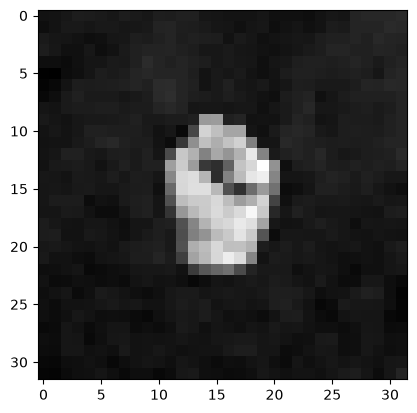

In [9]:
# train의 이미지 확인
plt.imshow(train_input[0], cmap='gray')
plt.show()

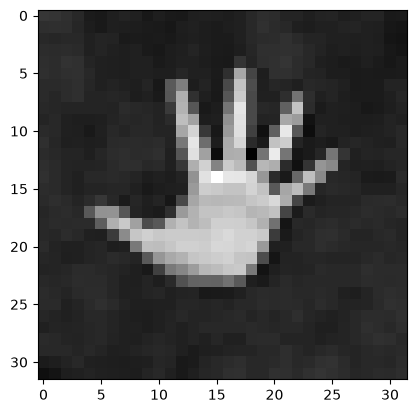

In [10]:
# test의 이미지 확인
plt.imshow(test_input[0], cmap='gray')
plt.show()

#### Numpy 배열로 변경

In [11]:
import numpy as np

In [12]:
# train data 만들기 (18000 * 32 * 32)

tempData = np.zeros(
   18000 * 32 * 32,
   dtype=np.int32
).reshape(18000,32,32)

i = 0
for image in train_input:
   img = np.array(image, dtype=np.int32)
   tempData[i,:,:] = img
   i+=1

train_input = tempData.copy()


In [13]:
# test data 만들기 (3600 * 32 * 32)

tempData = np.zeros(
   3600 * 32 * 32,
   dtype=np.int32
).reshape(3600,32,32)

i = 0
for image in test_input:
   img = np.array(image, dtype=np.int32)
   tempData[i,:,:] = img
   i+=1

test_input = tempData.copy()


In [14]:
train_input[0]

array([[51, 52, 55, ..., 66, 66, 68],
       [48, 52, 56, ..., 64, 68, 67],
       [57, 54, 53, ..., 67, 65, 63],
       ...,
       [47, 46, 54, ..., 51, 48, 50],
       [44, 43, 48, ..., 50, 54, 55],
       [42, 41, 46, ..., 47, 54, 64]], dtype=int32)

In [15]:
# 배열 크기 확인
print(train_input.shape, test_input.shape)

(18000, 32, 32) (3600, 32, 32)


----
#### target을 숫자로 변경하기

In [16]:
label_to_int = {
   '0R' : 0,
   '1R' : 1,
   '2R' : 2,
   '3R' : 3,
   '4R' : 4,
   '5R' : 5,
   '0L' : 6,
   '1L' : 7,
   '2L' : 8,
   '3L' : 9,
   '4L' : 10,
   '5L' : 11,
}

In [17]:
# train target 숫자로 변경
temp = []
for label in train_target:
   temp.append(label_to_int[label])
train_target = temp.copy()

In [18]:
# test target 숫자로 변경
temp = []
for label in test_target:
   temp.append(label_to_int[label])
test_target = temp.copy()

In [19]:
# Target도 numpy 배열로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

In [20]:
train_target[:5]

array([ 6,  6,  8,  6, 11])

In [21]:
test_target[:5]

array([11, 11,  3, 11, 11])

#### 심층신경망 구성해보기 (실습)

In [22]:
from sklearn.model_selection import train_test_split

train_scaled = (train_input / 255.0)

train_scaled, val_scaled, train_target, val_target = \
   train_test_split(
      train_scaled,
      train_target,
      test_size=0.2,
      random_state=42
   )

In [ ]:
# model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       102,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,712 (405.12 KB)

 Trainable params: 103,712 (405.12 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from tensorflow import keras

model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(32, 32))) 
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(50, activation='relu'))
model.add(keras.layers.Dense(12, activation='softmax'))

model.compile(
   optimizer='adam',
   loss='sparse_categorical_crossentropy',
   metrics=['accuracy']
)

model.fit(
   train_scaled, 
   train_target, 
   epochs=4
)

test_scaled = test_input / 255.0

print("Train :", model.evaluate(train_scaled, train_target))
print("Valid :", model.evaluate(val_scaled, val_target))
print("Test  :", model.evaluate(test_scaled, test_target))

Epoch 1/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7824 - loss: 0.8666
Epoch 2/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9591 - loss: 0.1697
Epoch 3/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9819 - loss: 0.0793
Epoch 4/4
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9898 - loss: 0.0470
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9917 - loss: 0.0386
Train : [0.03856772556900978, 0.991736114025116]
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9919 - loss: 0.0419
Valid : [0.04190187156200409, 0.991944432258606]
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9903 - loss: 0.0491
Test  : [0.049083009362220764, 0.9902777671813965]
